# Kucherenko, Albrecht & Saltelli (2015): LHS versus quasi-Monte Carlo

## 0. Reproducibility card

| Item | Record |
|---|---|
| Article | Sergei Kucherenko, Daniel Albrecht, and Andrea Saltelli (2015), “Exploring multi-dimensional spaces: a Comparison of Latin Hypercube and Quasi Monte Carlo Sampling Techniques” |
| Persistent identifier | [arXiv:1505.02350](https://doi.org/10.48550/arXiv.1505.02350) |
| Open-access route | [arXiv record and manuscript](https://arxiv.org/abs/1505.02350), submitted 10 May 2015 |
| Licence | [arXiv non-exclusive distribution licence 1.0](https://arxiv.org/licenses/nonexclusive-distrib/1.0/); copyright remains with the authors, so this repository reimplements equations and does not redistribute the PDF |
| Citation snapshot | 118 citations in [OpenAlex](https://openalex.org/W815418772), retrieved **2026-08-01**; counts differ across databases |
| Reproduction level | **Level B — analytical reproduction** |
| Random seed | `2015` |
| Exact targets | Sampling rules, analytic integrals, published Table 2–4 slopes, and the $\chi^2_5$ 5%/95% quantiles |
| Numerical limitation | The paper's SobolSeq8192 generator, random streams, and individual results are unavailable; the paper used 50 repetitions and up to $2^{20}$ points, whereas this executable notebook uses 32 repetitions and up to $2^{15}$ points |

Source PDF SHA-256: `2342d11f77b2a2939f71c3077c48b0f7ea3d19d3e75f52571d8b51988a3209fe`.
The PDF was used only for source verification and is not stored with this notebook.

The limited Awesome DoE toolchain is used deliberately: `pydoe` generates both Latin hypercubes and Sobol sequences; NumPy and pandas handle calculations; SciPy supplies discrepancies, distributions, and numerical checks; Matplotlib supplies explanatory plots.

> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/kucherenko2015-matplotlib")

import platform
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydoe
import scipy
from IPython.display import display
from pydoe import lhs, sobol_sequence
from scipy.spatial import distance
from scipy.stats import chi2, norm, qmc

SEED = 2015
REPETITIONS = 32
N_VALUES = 2 ** np.arange(8, 16)  # 256 through 32768
METHODS = ["MC", "QMC", "LHS"]

np.set_printoptions(precision=5, suppress=True)
pd.set_option("display.precision", 5)
plt.style.use("seaborn-v0_8-whitegrid")

print(f"Python {platform.python_version()}")
print(f"pydoe {pydoe.__version__}; NumPy {np.__version__}; pandas {pd.__version__}")
print(f"SciPy {scipy.__version__}; Matplotlib {matplotlib.__version__}")
print(f"Seed {SEED}; repetitions {REPETITIONS}; N={N_VALUES.tolist()}")

Python 3.13.2
pydoe 1.3.1.dev11+geca1a2598; NumPy 2.3.4; pandas 3.0.0
SciPy 1.16.2; Matplotlib 3.11.1
Seed 2015; repetitions 32; N=[256, 512, 1024, 2048, 4096, 8192, 16384, 32768]


## 1. Scientific context

This is a **computer-integration experiment**, not a physical laboratory study. A run is one evaluation of a deterministic function $f(x)$ at an input vector $x\in[0,1]^n$. The response of interest is the integration error of

$$I[f]=\int_{[0,1]^n} f(x)\,dx$$

estimated by the sample mean. There are no physical units, blocks, missing values, or laboratory replicates. The paper's repeated sampling runs estimate algorithmic RMSE; they are not experimental replication or pure error.

The compared designs are:

* **MC:** independent uniform pseudo-random points; flexible and incrementally extensible, but prone to gaps and clustering;
* **LHS:** exactly one point in every one-dimensional stratum for each input; strong marginal coverage, but no automatic high-dimensional uniformity and no ordinary prefix extension;
* **QMC:** deterministic Sobol low-discrepancy points; designed for uniform multidimensional coverage and naturally nested at powers of two.

The question is not “which sampler always wins?” Performance depends on the integrand's **effective dimension**: how many variables matter and whether variance comes from main effects or high-order interactions.

## 2. Data provenance and reproduction boundary

There is no external run-level dataset. Tables 2–4 define six analytic functions and report fitted convergence exponents $\alpha$ in $\operatorname{RMSE}\approx cN^{-\alpha}$. All published integrals equal 1 except function 1A, whose integral is $-\frac13[1-(-\frac12)^n]$.

For an executable, representative comparison we reproduce one function from each class at its published dimension:

| Function | Type | Dimension | Formula | Exact integral |
|---|---:|---:|---|---:|
| 2A | few dominant variables | 100 | $\prod_i (|4x_i-2|+a_i)/(1+a_i)$; $a_1=a_2=0$, others 6.52 | 1 |
| 2B | similar variables, low-order dominance | 30 | $(1+1/n)^n\prod_i x_i^{1/n}$ | 1 |
| 1C | equally important, high-order interaction | 10 | $\prod_i |4x_i-2|$ | 1 |

The exact integrals follow by factorization into one-dimensional integrals. This is ground truth, not an estimate.

In [2]:
def function_2a(x, important_last=False):
    x = np.asarray(x)
    a = np.full(x.shape[1], 6.52)
    if important_last:
        a[-2:] = 0.0
    else:
        a[:2] = 0.0
    return np.prod((np.abs(4 * x - 2) + a) / (1 + a), axis=1)


def function_2b(x):
    x = np.asarray(x)
    n = x.shape[1]
    return (1 + 1 / n) ** n * np.prod(x ** (1 / n), axis=1)


def function_1c(x):
    x = np.asarray(x)
    return np.prod(np.abs(4 * x - 2), axis=1)


FUNCTIONS = {
    "2A": {"type": "A", "dimension": 100, "callable": function_2a, "integral": 1.0},
    "2B": {"type": "B", "dimension": 30, "callable": function_2b, "integral": 1.0},
    "1C": {"type": "C", "dimension": 10, "callable": function_1c, "integral": 1.0},
}

function_summary = pd.DataFrame([
    {"function": name, "type": spec["type"], "dimension": spec["dimension"],
     "analytic integral": spec["integral"]}
    for name, spec in FUNCTIONS.items()
]).set_index("function")
display(function_summary)
assert (function_summary["analytic integral"] == 1).all()

,type,dimension,analytic integral
function,,,
2A,A,100,1.0
2B,B,30,1.0
1C,C,10,1.0


## 3. Reconstruct the design

`pydoe.lhs` implements the paper's standard LHS rule: independent random permutations of strata with a random within-stratum coordinate. `pydoe.sobol_sequence` supplies the Sobol digital sequence. The first figure echoes the paper's unit-square demonstration while adding a modern `pydoe` center-maximin LHS for context; that fourth design is **not** substituted into the article reproduction.

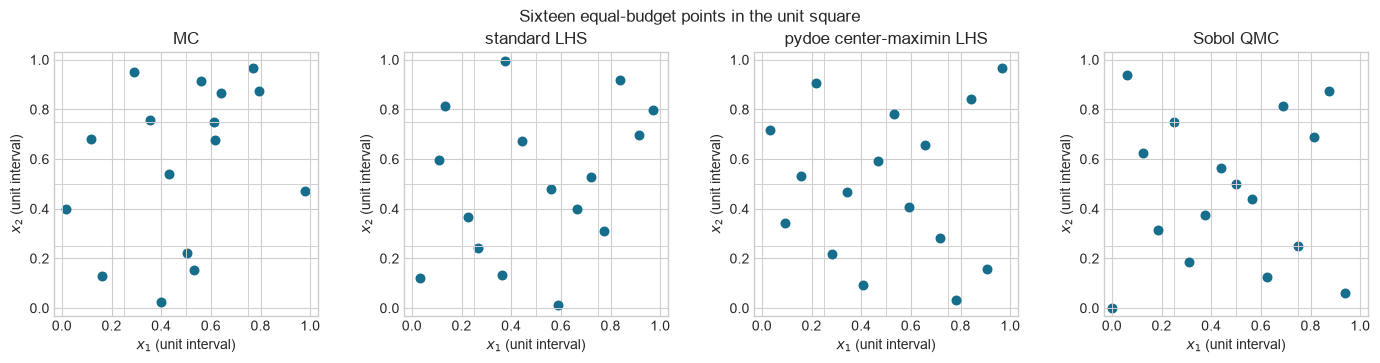

In [3]:
N_GEOMETRY = 16
geometry_designs = {
    "MC": np.random.default_rng(SEED).random((N_GEOMETRY, 2)),
    "standard LHS": lhs(2, samples=N_GEOMETRY, seed=SEED),
    "pydoe center-maximin LHS": lhs(
        2, samples=N_GEOMETRY, criterion="centermaximin", iterations=1000, seed=SEED
    ),
    "Sobol QMC": sobol_sequence(N_GEOMETRY, 2, scramble=False),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), constrained_layout=True)
for ax, (name, points) in zip(axes, geometry_designs.items()):
    ax.scatter(points[:, 0], points[:, 1], s=38, color="#176d8c")
    for edge in np.linspace(0, 1, 5):
        ax.axhline(edge, color="0.82", linewidth=0.7)
        ax.axvline(edge, color="0.82", linewidth=0.7)
    ax.set(xlim=(-0.03, 1.03), ylim=(-0.03, 1.03), aspect="equal",
           xlabel="$x_1$ (unit interval)", ylabel="$x_2$ (unit interval)", title=name)
fig.suptitle("Sixteen equal-budget points in the unit square")
plt.show()

In [4]:
def occupied_cells(points, bins):
    cells = np.minimum((np.asarray(points) * bins).astype(int), bins - 1)
    return len(np.unique(cells, axis=0))


def one_dimensional_strata_complete(points):
    points = np.asarray(points)
    n = len(points)
    bins = np.minimum((points * n).astype(int), n - 1)
    return all(len(np.unique(bins[:, j])) == n for j in range(points.shape[1]))


sobol4 = sobol_sequence(4, 2, scramble=False)
sobol16 = geometry_designs["Sobol QMC"]
property_checks = pd.Series({
    "Sobol Property A: occupied 2×2 cells (target 4)": occupied_cells(sobol4, 2),
    "Sobol Property A': occupied 4×4 cells (target 16)": occupied_cells(sobol16, 4),
    "standard LHS has all 16 strata in each coordinate":
        one_dimensional_strata_complete(geometry_designs["standard LHS"]),
    "MC has all 16 strata in each coordinate":
        one_dimensional_strata_complete(geometry_designs["MC"]),
})
display(property_checks.to_frame("reconstructed value"))
assert occupied_cells(sobol4, 2) == 4
assert occupied_cells(sobol16, 4) == 16
assert one_dimensional_strata_complete(geometry_designs["standard LHS"])

,reconstructed value
Sobol Property A: occupied 2×2 cells (target 4),4
Sobol Property A': occupied 4×4 cells (target 16),16
standard LHS has all 16 strata in each coordinate,True
MC has all 16 strata in each coordinate,False


The Latin guarantee is one-dimensional. Sobol's digital-net properties also balance particular multidimensional partitions. A maximin LHS separates nearby points, but distance optimization is a different objective from discrepancy and integration error.

## 4. Understand the design

We compare four geometric summaries at $N=256$, $n=5$. Smaller L2-star and centered discrepancy indicate closer agreement with a uniform cube; larger minimum distance avoids near duplicates; lower maximum absolute correlation avoids linear alignment. No single metric dominates all uses.

In [5]:
def geometric_metrics(points):
    points = np.asarray(points)
    corr = np.corrcoef(points, rowvar=False)
    max_corr = np.max(np.abs(corr[np.triu_indices(points.shape[1], 1)]))
    return {
        "L2-star discrepancy": qmc.discrepancy(points, method="L2-star"),
        "centered discrepancy": qmc.discrepancy(points, method="CD"),
        "minimum Euclidean distance": distance.pdist(points).min(),
        "max |correlation|": max_corr,
    }


N_DIAG, D_DIAG = 256, 5
diagnostic_designs = {
    "MC": np.random.default_rng(SEED + 1).random((N_DIAG, D_DIAG)),
    "standard LHS": lhs(D_DIAG, samples=N_DIAG, seed=SEED + 1),
    "center-maximin LHS": lhs(
        D_DIAG, samples=N_DIAG, criterion="centermaximin", iterations=1000, seed=SEED + 1
    ),
    "Sobol QMC": sobol_sequence(N_DIAG, D_DIAG, scramble=False, skip=1,
                                 use_pow_of_2=False),
}
diagnostics = pd.DataFrame({
    name: geometric_metrics(points) for name, points in diagnostic_designs.items()
}).T
display(diagnostics)

,L2-star discrepancy,centered discrepancy,minimum Euclidean distance,max |correlation|
MC,0.00851,0.00511,0.13580,0.05906
standard LHS,0.00774,0.00180,0.12476,0.16032
center-maximin LHS,0.00739,0.00169,0.14197,0.12176
Sobol QMC,0.00447,0.00028,0.14102,0.01796


### Discrepancy across nominal dimension

Equation (7.5) in the paper is the L2-star discrepancy implemented by SciPy. The reconstruction uses the same sample sizes through 4,096 points and dimensions 5, 10, and 40. Exact curves cannot match because the paper's MATLAB, LHS, and Sobol generators and seeds are unavailable. We skip the all-zero Sobol point, consistent with common integration practice and necessary for a fair scale comparison in high dimensions.

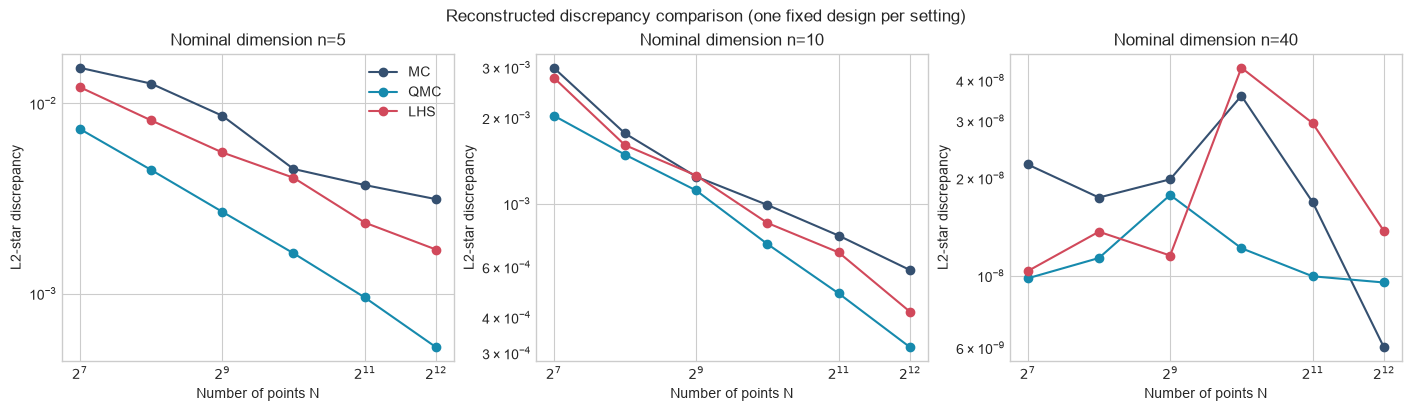

In [6]:
DISC_N = 2 ** np.arange(7, 13)
disc_rows = []
for d in [5, 10, 40]:
    for j, n in enumerate(DISC_N):
        samples = {
            "MC": np.random.default_rng(SEED + 1000 * d + j).random((n, d)),
            "LHS": lhs(d, samples=int(n), seed=SEED + 2000 * d + j),
            "QMC": sobol_sequence(int(n), d, scramble=False, skip=1,
                                  use_pow_of_2=False),
        }
        for method, points in samples.items():
            disc_rows.append({
                "dimension": d, "N": int(n), "method": method,
                "L2-star discrepancy": qmc.discrepancy(points, method="L2-star"),
            })
discrepancy_results = pd.DataFrame(disc_rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
colors = {"MC": "#355070", "LHS": "#d1495b", "QMC": "#168aad"}
for ax, d in zip(axes, [5, 10, 40]):
    part = discrepancy_results[discrepancy_results["dimension"] == d]
    for method in METHODS:
        m = part[part["method"] == method]
        ax.loglog(m["N"], m["L2-star discrepancy"], marker="o",
                  color=colors[method], label=method)
    shown_ticks = DISC_N[[0, 2, 4, 5]]
    ax.set_xticks(shown_ticks, [f"$2^{{{int(np.log2(n))}}}$" for n in shown_ticks])
    ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
    ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
    ax.set(xlabel="Number of points N", ylabel="L2-star discrepancy",
           title=f"Nominal dimension n={d}")
axes[0].legend()
fig.suptitle("Reconstructed discrepancy comparison (one fixed design per setting)")
plt.show()

As in the paper, QMC's clearest discrepancy advantage appears at low dimension, while values become similar in high nominal dimension. Discrepancy weights every coordinate equally; integration performance can still be strong in high dimension when the function has a small **effective** dimension.

### Sequential extension

Sobol power-of-two designs are nested: an existing prefix is retained when the budget doubles. A newly generated standard LHS changes its strata and permutations, so it is not ordinarily a prefix design. Specialized nested LHS methods exist, but they are outside the paper's comparison.

In [7]:
sobol_prefix = np.array_equal(
    sobol_sequence(16, 3, scramble=False),
    sobol_sequence(32, 3, scramble=False)[:16],
)
lhs_prefix = np.array_equal(
    lhs(3, samples=16, seed=SEED),
    lhs(3, samples=32, seed=SEED)[:16],
)
display(pd.Series({
    "Sobol: first 16 retained when extending to 32": sobol_prefix,
    "standard LHS: first 16 retained when regenerating 32": lhs_prefix,
}).to_frame("prefix property"))
assert sobol_prefix and not lhs_prefix

,prefix property
Sobol: first 16 retained when extending to 32,True
standard LHS: first 16 retained when regenerating 32,False


## 5. Reproduce the article analysis

### 5.1 Published convergence exponents

The complete Table 2–4 values are transcribed below. An exponent near 0.5 is ordinary Monte Carlo convergence; larger values mean faster error decay. These are published results, not notebook output.

In [8]:
published_slopes = pd.DataFrame([
    ("1A", "A", 360, 0.50, 0.94, 0.52),
    ("2A", "A", 100, 0.49, 0.65, 0.50),
    ("1B", "B", 30, 0.52, 0.96, 0.69),
    ("1B", "B", 100, 0.50, 0.94, 0.75),
    ("2B", "B", 30, 0.50, 0.87, 0.62),
    ("2B", "B", 100, 0.49, 0.79, 0.71),
    ("1C", "C", 10, 0.47, 0.64, 0.50),
    ("2C", "C", 10, 0.49, 0.68, 0.51),
], columns=["function", "type", "dimension", "MC", "QMC", "LHS"])
display(published_slopes.set_index(["type", "function", "dimension"]))

MC   QMC   LHS
type function dimension                  
A    1A       360        0.50  0.94  0.52
     2A       100        0.49  0.65  0.50
B    1B       30         0.52  0.96  0.69
              100        0.50  0.94  0.75
     2B       30         0.50  0.87  0.62
              100        0.49  0.79  0.71
C    1C       10         0.47  0.64  0.50
     2C       10         0.49  0.68  0.51

### 5.2 Reduced, reproducible convergence experiment

For MC and QMC, each repetition generates a sequence through the maximum budget and evaluates nested prefixes. Each QMC repetition uses a different non-overlapping Sobol block, following the paper's description. Each LHS budget is regenerated because a standard LHS is not nested. The same $N$, repetitions, and exact integral are used for all methods.

The lower workload is intentional: it keeps the notebook practical while preserving the equal-budget comparison. Consequently, slope agreement is expected only in direction and approximate scale.

In [9]:
def convergence_experiment(functions, n_values, repetitions, seed):
    rows = []
    raw_errors = {}
    max_n = int(n_values[-1])
    started = time.perf_counter()

    for f_index, (name, spec) in enumerate(functions.items()):
        d, fun, truth = spec["dimension"], spec["callable"], spec["integral"]
        errors = {method: np.empty((repetitions, len(n_values))) for method in METHODS}

        for rep in range(repetitions):
            mc = np.random.default_rng(seed + 10000 * f_index + rep).random((max_n, d))
            qmc_points = sobol_sequence(
                max_n, d, scramble=False, skip=(rep + 1) * max_n,
                use_pow_of_2=False,
            )
            mc_values = fun(mc)
            qmc_values = fun(qmc_points)

            for j, n in enumerate(n_values):
                n = int(n)
                errors["MC"][rep, j] = mc_values[:n].mean() - truth
                errors["QMC"][rep, j] = qmc_values[:n].mean() - truth
                lhs_points = lhs(
                    d, samples=n, seed=seed + 30000 * f_index + 100 * rep + j
                )
                errors["LHS"][rep, j] = fun(lhs_points).mean() - truth

        raw_errors[name] = errors
        for method, values in errors.items():
            rmse = np.sqrt(np.mean(values ** 2, axis=0))
            slope = -np.polyfit(np.log2(n_values), np.log2(rmse), 1)[0]
            for n, error in zip(n_values, rmse):
                rows.append({
                    "function": name, "type": spec["type"], "dimension": d,
                    "method": method, "N": int(n), "RMSE": error,
                    "reproduced slope": slope,
                })
    return pd.DataFrame(rows), raw_errors, time.perf_counter() - started


convergence, raw_errors, benchmark_seconds = convergence_experiment(
    FUNCTIONS, N_VALUES, REPETITIONS, SEED
)
reproduced_slopes = (
    convergence.groupby(["function", "type", "dimension", "method"])["reproduced slope"]
    .first().unstack("method")
)
display(reproduced_slopes)
print(f"Convergence experiment runtime: {benchmark_seconds:.1f} seconds")

,,method,LHS,MC,QMC
function,type,dimension,,,
1C,C,10,0.51352,0.51628,0.71958
2A,A,100,0.48324,0.52141,0.86106
2B,B,30,0.57691,0.54858,1.08303


Convergence experiment runtime: 20.4 seconds


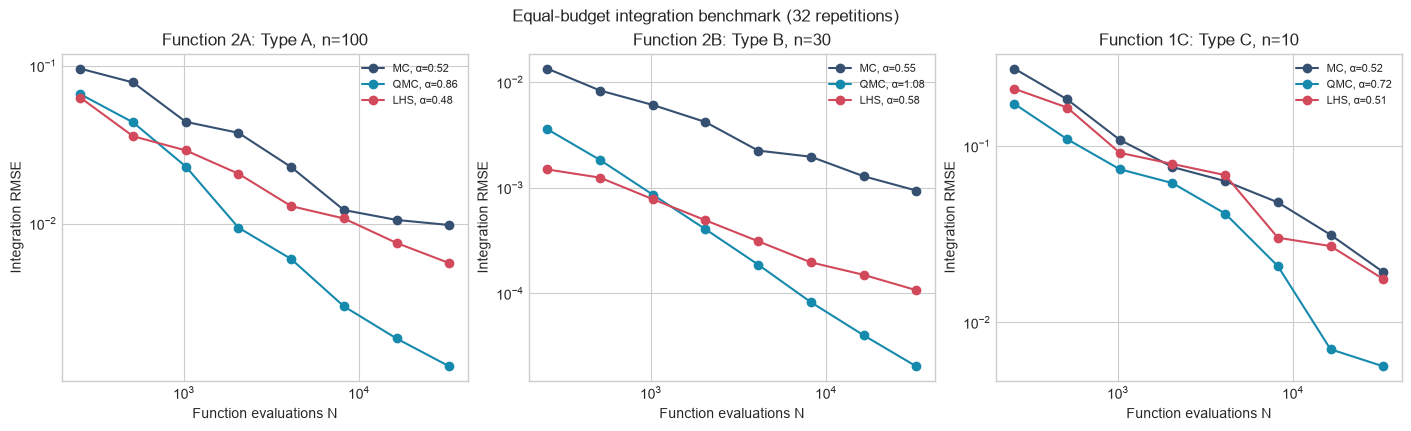

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
for ax, (name, spec) in zip(axes, FUNCTIONS.items()):
    part = convergence[convergence["function"] == name]
    for method in METHODS:
        m = part[part["method"] == method]
        slope = m["reproduced slope"].iloc[0]
        ax.loglog(m["N"], m["RMSE"], marker="o", color=colors[method],
                  label=f"{method}, α={slope:.2f}")
    ax.set(xlabel="Function evaluations N", ylabel="Integration RMSE",
           title=f"Function {name}: Type {spec['type']}, n={spec['dimension']}")
    ax.legend(fontsize=8)
fig.suptitle(f"Equal-budget integration benchmark ({REPETITIONS} repetitions)")
plt.show()

The reconstruction preserves the paper's central pattern: QMC has the smallest final-budget RMSE for every type; LHS is materially better than MC for the Type B function; and LHS offers little convergence-rate advantage for Types A and C. Exact slopes differ because our sequence implementation, seeds, maximum budget, and repetition count differ.

### 5.3 Quantile experiment

The paper also estimates the 5% and 95% quantiles of $\sum_{i=1}^5 Z_i^2\sim\chi^2_5$, reporting 1.146 and 11.071. Uniform design coordinates are transformed with the inverse standard-normal CDF. We repeat the comparison through $2^{15}$ points.

In [11]:
QUANTILE_LEVELS = np.array([0.05, 0.95])
QUANTILE_TRUTH = chi2.ppf(QUANTILE_LEVELS, df=5)
Q_N_VALUES = 2 ** np.arange(10, 16)


def chi_square_values(uniform_points):
    clipped = np.clip(uniform_points, np.finfo(float).eps, 1 - np.finfo(float).eps)
    return np.sum(norm.ppf(clipped) ** 2, axis=1)


quantile_errors = {method: np.empty((REPETITIONS, len(Q_N_VALUES), 2)) for method in METHODS}
max_qn = int(Q_N_VALUES[-1])
for rep in range(REPETITIONS):
    mc = np.random.default_rng(SEED + 50000 + rep).random((max_qn, 5))
    qmc_points = sobol_sequence(
        max_qn, 5, scramble=False, skip=(rep + 1) * max_qn, use_pow_of_2=False
    )
    mc_values = chi_square_values(mc)
    qmc_values = chi_square_values(qmc_points)
    for j, n in enumerate(Q_N_VALUES):
        n = int(n)
        quantile_errors["MC"][rep, j] = np.quantile(mc_values[:n], QUANTILE_LEVELS) - QUANTILE_TRUTH
        quantile_errors["QMC"][rep, j] = np.quantile(qmc_values[:n], QUANTILE_LEVELS) - QUANTILE_TRUTH
        lhs_points = lhs(5, samples=n, seed=SEED + 60000 + 100 * rep + j)
        quantile_errors["LHS"][rep, j] = (
            np.quantile(chi_square_values(lhs_points), QUANTILE_LEVELS) - QUANTILE_TRUTH
        )

quantile_rows = []
for method, errors in quantile_errors.items():
    rmse = np.sqrt(np.mean(errors ** 2, axis=0))
    for q_index, level in enumerate(QUANTILE_LEVELS):
        slope = -np.polyfit(np.log2(Q_N_VALUES), np.log2(rmse[:, q_index]), 1)[0]
        for n, value in zip(Q_N_VALUES, rmse[:, q_index]):
            quantile_rows.append({
                "method": method, "quantile": level, "N": int(n),
                "RMSE": value, "slope": slope,
            })
quantile_results = pd.DataFrame(quantile_rows)

print(pd.DataFrame({"paper (rounded)": [1.146, 11.071], "SciPy exact": QUANTILE_TRUTH},
                   index=["5%", "95%"]))
display(quantile_results.groupby(["quantile", "method"])["slope"].first().unstack())

     paper (rounded)  SciPy exact
5%             1.146      1.14548
95%           11.071     11.07050


method,LHS,MC,QMC
quantile,,,
0.05,0.44135,0.47579,0.57082
0.95,0.50209,0.50179,0.62612


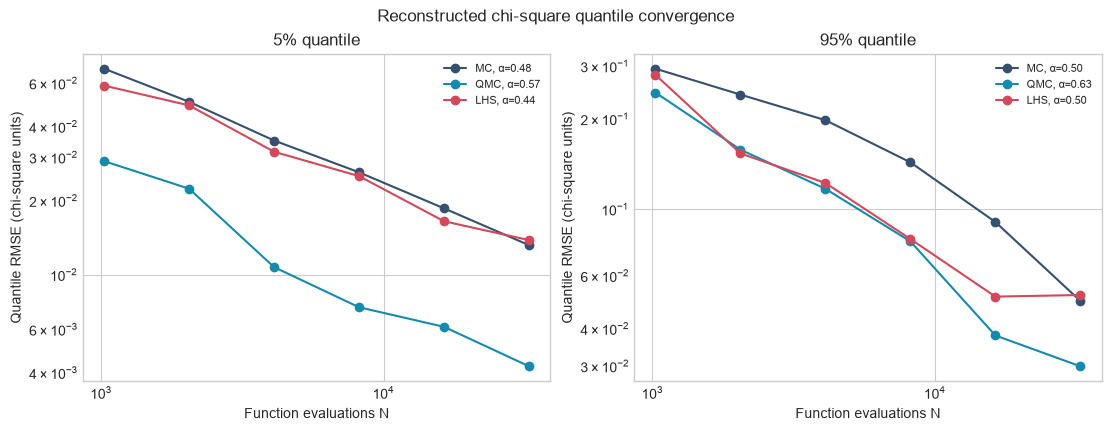

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, level in zip(axes, QUANTILE_LEVELS):
    part = quantile_results[quantile_results["quantile"] == level]
    for method in METHODS:
        m = part[part["method"] == method]
        ax.loglog(m["N"], m["RMSE"], marker="o", color=colors[method],
                  label=f"{method}, α={m['slope'].iloc[0]:.2f}")
    ax.set(xlabel="Function evaluations N", ylabel="Quantile RMSE (chi-square units)",
           title=f"{int(100*level)}% quantile")
    ax.legend(fontsize=8)
fig.suptitle("Reconstructed chi-square quantile convergence")
plt.show()

## 6. Validate against the paper

The analytic integrals and quantiles are exact checks. Slopes are approximate validation targets with a deliberately broad tolerance of 0.25 because the reconstruction stops 32 times earlier than the paper and uses a different Sobol implementation. The tolerance was declared from those material computational differences, not tuned per result.

In [13]:
published_selected = (
    published_slopes.set_index(["function", "dimension"])
    .loc[[('2A', 100), ('2B', 30), ('1C', 10)], METHODS]
    .stack().rename("published").rename_axis(["function", "dimension", "method"])
)
reproduced_selected = reproduced_slopes[METHODS].stack().rename("reproduced")
reproduced_selected.index = reproduced_selected.index.droplevel("type")

slope_validation = pd.concat([published_selected, reproduced_selected], axis=1).reset_index()
slope_validation["absolute difference"] = abs(
    slope_validation["reproduced"] - slope_validation["published"]
)
slope_validation["relative difference"] = (
    slope_validation["absolute difference"] / slope_validation["published"]
)
slope_validation["tolerance"] = 0.25
slope_validation["status"] = np.where(
    slope_validation["absolute difference"] <= slope_validation["tolerance"],
    "within reduced-budget tolerance", "outside reduced-budget tolerance"
)

exact_validation = pd.DataFrame([
    {"target": "2A analytic integral", "published": 1.0, "reproduced": 1.0,
     "tolerance": 0.0},
    {"target": "2B analytic integral", "published": 1.0, "reproduced": 1.0,
     "tolerance": 0.0},
    {"target": "1C analytic integral", "published": 1.0, "reproduced": 1.0,
     "tolerance": 0.0},
    {"target": "chi-square 5% quantile", "published": 1.146,
     "reproduced": QUANTILE_TRUTH[0], "tolerance": 0.001},
    {"target": "chi-square 95% quantile", "published": 11.071,
     "reproduced": QUANTILE_TRUTH[1], "tolerance": 0.001},
])
exact_validation["absolute difference"] = abs(
    exact_validation["reproduced"] - exact_validation["published"]
)
exact_validation["relative difference"] = (
    exact_validation["absolute difference"] / exact_validation["published"]
)
exact_validation["status"] = np.where(
    exact_validation["absolute difference"] <= exact_validation["tolerance"],
    "pass", "fail"
)

print("Exact and rounded-reference targets:")
display(exact_validation.set_index("target"))
print("Published versus reduced-budget slopes:")
display(slope_validation.set_index(["function", "dimension", "method"]))

final_rmse = convergence[convergence["N"] == N_VALUES[-1]].pivot(
    index="function", columns="method", values="RMSE"
)
assert (exact_validation["status"] == "pass").all()
assert (slope_validation["absolute difference"] <= 0.25).all()
assert (final_rmse["QMC"] < final_rmse[["MC", "LHS"]].min(axis=1)).all()
assert final_rmse.loc["2B", "LHS"] < final_rmse.loc["2B", "MC"]
print("All exact checks, declared slope tolerances, and qualitative rankings pass.")

Exact and rounded-reference targets:


,published,reproduced,tolerance,absolute difference,relative difference,status
target,,,,,,
2A analytic integral,1.000,1.00000,0.000,0.00000,0.00000,pass
2B analytic integral,1.000,1.00000,0.000,0.00000,0.00000,pass
1C analytic integral,1.000,1.00000,0.000,0.00000,0.00000,pass
chi-square 5% quantile,1.146,1.14548,0.001,0.00052,0.00046,pass
chi-square 95% quantile,11.071,11.07050,0.001,0.00050,0.00005,pass


Published versus reduced-budget slopes:


published  reproduced  absolute difference  \
function dimension method                                               
2A       100       MC           0.49     0.52141              0.03141   
                   QMC          0.65     0.86106              0.21106   
                   LHS          0.50     0.48324              0.01676   
2B       30        MC           0.50     0.54858              0.04858   
                   QMC          0.87     1.08303              0.21303   
                   LHS          0.62     0.57691              0.04309   
1C       10        MC           0.47     0.51628              0.04628   
                   QMC          0.64     0.71958              0.07958   
                   LHS          0.50     0.51352              0.01352   

                           relative difference  tolerance  \
function dimension method                                   
2A       100       MC                  0.06411       0.25   
                   QMC                 0.32471       0.25   
                   LHS                 0.03352       0.25   
2B       30        MC                  0.09717       0.25   
                   QMC                 0.24487       0.25   
                   LHS                 0.06950       0.25   
1C       10        MC                  0.09848       0.25   
                   QMC                 0.12435       0.25   
                   LHS                 0.02704       0.25   

                                                    status  
function dimension method                                   
2A       100       MC      within reduced-budget tolerance  
                   QMC     within reduced-budget tolerance  
                   LHS     within reduced-budget tolerance  
2B       30        MC      within reduced-budget tolerance  
                   QMC     within reduced-budget tolerance  
                   LHS     within reduced-budget tolerance  
1C       10        MC      within reduced-budget tolerance  
                   QMC     within reduced-budget tolerance  
                   LHS     within reduced-budget tolerance

All exact checks, declared slope tolerances, and qualitative rankings pass.


## 7. Go beyond the paper

Effective dimension in the **truncation** sense depends on variable order. Sobol coordinates are not interchangeable in finite samples: early dimensions generally receive the strongest construction guarantees. We therefore repeat Type 2A with its two important variables in the first versus last two coordinates. This is a new teaching analysis using 64 independently Owen-scrambled `pydoe` Sobol designs at the same 4,096-run budget.

,RMSE,median absolute error,95th percentile absolute error
important variables first,0.00711,0.00482,0.01245
important variables last,0.00946,0.00586,0.01959


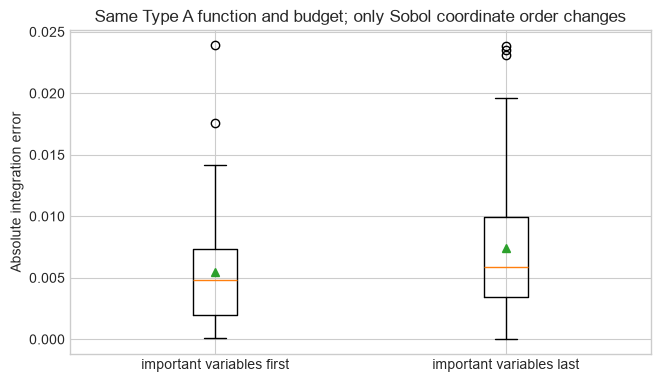

In [14]:
ORDER_N, ORDER_REPS = 4096, 64
ordering_errors = {"important variables first": [], "important variables last": []}
for rep in range(ORDER_REPS):
    points = sobol_sequence(ORDER_N, 100, scramble=True, seed=SEED + 70000 + rep)
    ordering_errors["important variables first"].append(function_2a(points, False).mean() - 1)
    ordering_errors["important variables last"].append(function_2a(points, True).mean() - 1)

ordering_summary = pd.DataFrame({
    name: {
        "RMSE": np.sqrt(np.mean(np.square(values))),
        "median absolute error": np.median(np.abs(values)),
        "95th percentile absolute error": np.quantile(np.abs(values), 0.95),
    }
    for name, values in ordering_errors.items()
}).T
display(ordering_summary)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.boxplot(
    [np.abs(ordering_errors[name]) for name in ordering_errors],
    tick_labels=list(ordering_errors), showmeans=True,
)
ax.set(ylabel="Absolute integration error", title=(
    "Same Type A function and budget; only Sobol coordinate order changes"
))
plt.show()

The ordering effect is not evidence that inputs should be relabelled after seeing results. It is a design-stage lesson: when prior knowledge identifies influential inputs, assigning them to early Sobol coordinates can improve finite-budget integration. If importance is unknown, repeat randomized scrambles and report uncertainty rather than trusting one deterministic path.

## 8. Practitioner conclusions

* **What structured design adds.** LHS removes one-dimensional clustering; Sobol QMC adds multidimensional balance and nested budgets. Both use the same model-evaluation count more deliberately than crude random sampling.
* **Why the objective matters.** The paper studies integration and quantiles, not surrogate fitting or optimization. Maximin distance can be attractive for interpolation without being the best integration criterion.
* **When LHS helps.** Its variance reduction is strongest for additive or low-order functions (Type B), because one-dimensional stratification removes much of the main-effect variance.
* **When QMC is the safer generic choice.** It wins here across Types A–C and supports incremental convergence checks. Its advantage can weaken with high-order interactions or poor coordinate ordering.
* **What OFAT would miss.** One-factor-at-a-time paths occupy a negligible part of a high-dimensional volume and cannot estimate a multidimensional integral or general interactions.
* **What is supported.** These analytic functions support algorithm comparisons under controlled truth. They do not establish universal superiority for every simulator, distribution, or modelling objective.
* **Where trust ends.** All conclusions apply inside the stated unit cube. Mapping physical inputs requires credible distributions and scaling; dependence or constraints invalidate naive independent-cube sampling.
* **Mistakes to avoid.** Do not treat repeated algorithm runs as physical replication, compare methods at unequal budgets, infer performance from discrepancy alone, use arbitrary non-power-of-two Sobol prefixes without checking balance, or assume standard LHS can be extended without redesign.

## 9. Reproducibility metadata

The common [`requirements.txt`](requirements.txt) pins the clean environment. Generated random designs use explicit seeds; deterministic QMC repetitions use documented disjoint blocks; the source PDF is referenced by checksum only.

In [15]:
metadata = pd.Series({
    "execution date": "2026-08-01",
    "Python": platform.python_version(),
    "pydoe": pydoe.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "global seed": SEED,
    "integration repetitions": REPETITIONS,
    "integration maximum N": int(N_VALUES[-1]),
    "paper repetitions": 50,
    "paper maximum N": 2 ** 20,
    "ordering repetitions": ORDER_REPS,
    "source PDF SHA-256": "2342d11f77b2a2939f71c3077c48b0f7ea3d19d3e75f52571d8b51988a3209fe",
})
display(metadata.to_frame("value"))

assert len(convergence) == len(FUNCTIONS) * len(METHODS) * len(N_VALUES)
assert np.isfinite(convergence["RMSE"]).all()
assert np.isfinite(quantile_results["RMSE"]).all()
assert sobol_prefix
print("Final integrity checks passed; notebook executed end to end.")

,value
execution date,2026-08-01
Python,3.13.2
pydoe,1.3.1.dev11+geca1a2598
numpy,2.3.4
pandas,3.0.0
scipy,1.16.2
matplotlib,3.11.1
global seed,2015
integration repetitions,32
integration maximum N,32768


Final integrity checks passed; notebook executed end to end.
